## Plotting and manipulating images 

Now that you have some understanding of numpy arrays, we will begin working with images. We will use certain image libraries that will assist with loading, plotting, and manipulating images. 

At several points in the lab, there are questions for your self-assessment. I strongly urge you to not skip those and ask the instructor if you are not sure. At other points, there are questions for which you will get feedback right away if you have passed the tests. After you have completed the notebook, you will need to submit the notebook on Canvas and I will send your file through the autograder.

## Matplotlib

Some of the content in this notebook is taken from the tutorial adapted by Kevin Zakka for the Spring 2020 edition of [cs231n](http://cs231n.stanford.edu/) and some from the image processing course by [Guillaume Witz](https://github.com/guiwitz).

In this lab, we will cover:
* Matplotlib: Plotting, Subplots, Images
* Image manipulation: Modify images (that are simply numpy arrays)

### What is Matplotlib?

Matplotlib is a plotting library. In this section give a brief introduction to the `matplotlib.pyplot` module, which provides a plotting system similar to that of MATLAB.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import matplotlib as matplt
matplt.__version__

'3.9.1'

By running this special iPython command, we will be displaying plots inline:

In [3]:
%matplotlib inline

### Plotting

The most important function in `matplotlib` is plot, which allows you to plot 2D data. Here is a simple example:

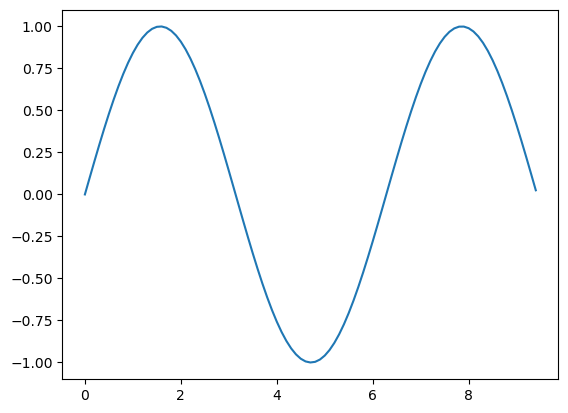

In [4]:
# Compute the x and y coordinates for points on a sine curve
x = np.arange(0, 3 * np.pi, 0.1)
y = np.sin(x)

# Plot the points using matplotlib
plt.plot(x, y)

With just a little bit of extra work we can easily plot multiple lines at once, and add a title, legend, and axis labels:

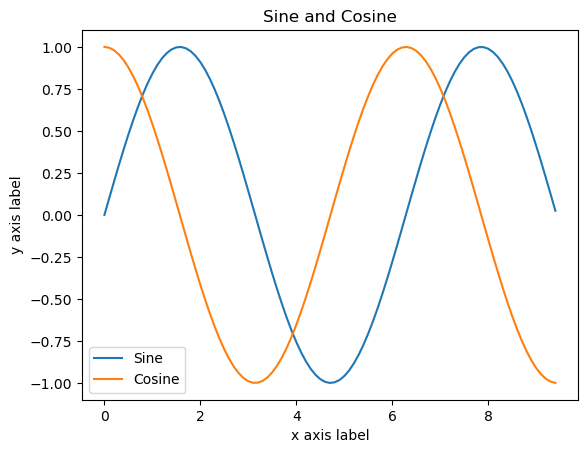

In [5]:
y_sin = np.sin(x)
y_cos = np.cos(x)

# Plot the points using matplotlib
plt.plot(x, y_sin)
plt.plot(x, y_cos)
plt.xlabel('x axis label')
plt.ylabel('y axis label')
plt.title('Sine and Cosine')
plt.legend(['Sine', 'Cosine'])

### Subplots 

You can plot different things in the same figure using the subplot function. Here is an example:

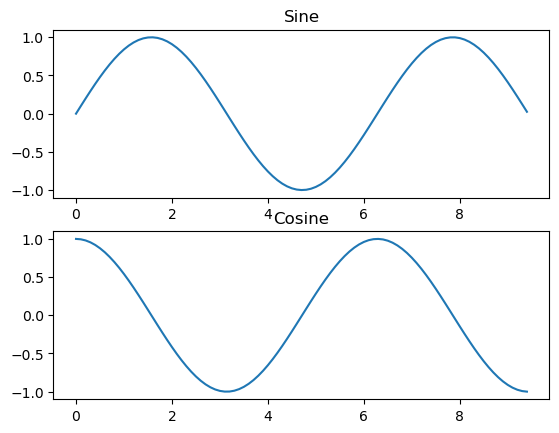

In [6]:
# Compute the x and y coordinates for points on sine and cosine curves
x = np.arange(0, 3 * np.pi, 0.1)
y_sin = np.sin(x)
y_cos = np.cos(x)

# Set up a subplot grid that has height 2 and width 1,
# and set the first such subplot as active.
plt.subplot(2, 1, 1)

# Make the first plot
plt.plot(x, y_sin)
plt.title('Sine')

# Set the second subplot as active, and make the second plot.
plt.subplot(2, 1, 2)
plt.plot(x, y_cos)
plt.title('Cosine')

# Show the figure.
plt.show()

You can read much more about the `subplot` function in the [documentation](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplot.html?highlight=subplot#matplotlib.pyplot.subplot) and further [examples](https://matplotlib.org/stable/gallery/subplots_axes_and_figures/subplots_demo.html).

A comprehensive tutorial on using Matplotlib is also available [here](https://github.com/rougier/matplotlib-tutorial)

## Plotting images with Matplotlib

This tutorial was originally written by [Justin Johnson](https://web.eecs.umich.edu/~justincj/) for Stanford's [cs231n](http://cs231n.stanford.edu/) and adapted as a Jupyter notebook for cs228 by [Volodymyr Kuleshov](http://web.stanford.edu/~kuleshov/) and [Isaac Caswell](https://symsys.stanford.edu/viewing/symsysaffiliate/21335), and later by Kevin Zakka for the Spring 2020 edition of [cs231n](http://cs231n.stanford.edu/).


Recall, ```list``` in Python is one of the **structures** to store sequence of numbers. If we think of an image that has multiple lines and columns of pixels, we could now imagine that we can represent it as a list of lists, each single list being e.g. one row of pixels. For example a 3 x 3 image could be:

In [7]:
my_image = [[4,8,7], [6,4,3], [5,3,7]]
my_image

[[4, 8, 7], [6, 4, 3], [5, 3, 7]]

While in principle we could use a ```list``` for this, computations on such objects would be very slow. For example if we wanted to do background correction and subtract a given value from our image, effectively we would have to go through each element of our list (each pixel) one by one and sequentially remove the background from each pixel. If the background is 3 we would have therefore to compute:
- 4-3
- 8-3
- 7-3
- 6-3

etc. Since operations are done sequentially this would be very slow as we couldn't exploit the fact that most computers have multiple processors. Also it would be tedious to write such an operation.

To fix this, most scientific areas that use lists of numbers of some kind (time-series, images, measurements etc.) resort to ```Numpy``` which offers a **computationally efficient list** called an **array**.

To make this clearer we now import an image in our notebook to see such a structure. Let us begin by importing the library skimage (short for [scikit-image](https://pypi.org/project/scikit-image/)) and certain subpackages: 

In [8]:
import os #for file operations
import skimage #for image operations

# most functions are in subpackages
from skimage import data #gives access to data already contained in this package such as images
from skimage import io #gives access to functions to read, process, and write images

We will load our image using the [data module](https://scikit-image.org/docs/stable/api/skimage.data.html) of skimage that we just imported.

In [9]:
#read the astronaut image from skimage
img = data.astronaut()
img

array([[[154, 147, 151],
        [109, 103, 124],
        [ 63,  58, 102],
        ...,
        [127, 120, 115],
        [120, 117, 106],
        [125, 119, 110]],

       [[177, 171, 171],
        [144, 141, 143],
        [113, 114, 124],
        ...,
        [127, 118, 112],
        [124, 115, 108],
        [121, 116, 105]],

       [[201, 194, 193],
        [182, 178, 175],
        [168, 165, 164],
        ...,
        [128, 120, 117],
        [126, 116, 112],
        [124, 114, 109]],

       ...,

       [[186, 170, 176],
        [186, 170, 177],
        [183, 168, 170],
        ...,
        [  0,   0,   0],
        [  0,   0,   1],
        [  0,   0,   0]],

       [[183, 169, 170],
        [182, 167, 171],
        [185, 164, 176],
        ...,
        [  0,   0,   1],
        [  1,   1,   1],
        [  0,   0,   0]],

       [[184, 167, 172],
        [183, 165, 169],
        [180, 162, 171],
        ...,
        [  0,   0,   0],
        [  1,   1,   1],
        [  0,   0,   0]]

We see here an output which is what is returned by our function. It is as expected a list of numbers, and not all numbers are shown because the list is too long. We see that we also have ```[]``` to specify rows, columns etc. The main difference compared to our list of lists that we defined previously is the ```array``` indication at the very beginning of the list of numbers. This ```array``` indication tells us that we are dealing with a ```Numpy``` array, this alternative type of list of lists that will allow us to do efficient computations. We are also given the datatype of this array in the field `dtype` (in this case, it is `uint8` or unsigned integer 8 bits).

### Displaying images
Now, we will use the ```imshow()``` function from the `Matplotlib` library to display images. There are many options for plot, but we will use that function by just passing an ```array``` as an input.

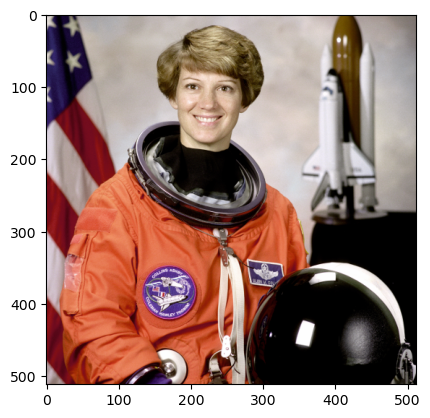

In [10]:
plt.imshow(img)

Clearly this is a color image. It has three channels R, G and B. Let us verify by checking the shape of the img array.

In [11]:
print(img.shape)

(512, 512, 3)


These numbers tell us that our array has 512 rows and 512 columns and 3 color channels. In the above output (few cells up) we also see an indication ```dtype```. This tells us what is the type of the pixels inside the array. The variable ```img``` is an array but its content can vary: we could have floating point values, integers etc. here ```uint8``` tells us we have unsigned (no negative values) integers in 8 bit, i.e. up to $2^{8}$ different possible pixel values.

## What's stored in a single channel of a color image?

Let us extract the red channel and display it. Red channel is the first of the three color channels. To display it we need:
- all rows of the first dimension: ```:```
- all columns of the second dimension: ```:```
- the first channel of the third dimension: ```0```

If this is unclear, flag the instructor!

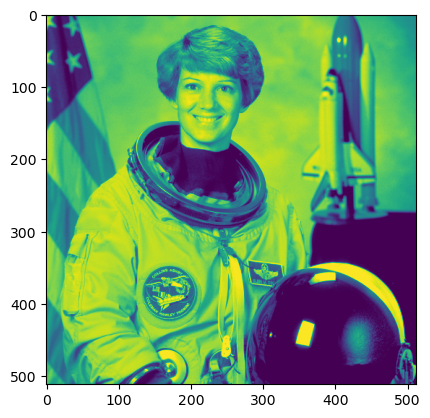

In [12]:
red = img[:, :, 0] 
plt.imshow(red)

The image should be gray-scale, then why does it look "colored"? Because, a default [colormap](https://matplotlib.org/stable/tutorials/colors/colormaps.html) has been applied on it (specifically [virdis](https://matplotlib.org/stable/users/prev_whats_new/dflt_style_changes.html#colormap)). We can change the default colormap through an optional parameter called `cmap` that allows us to set a certain colormap, here a gray one.

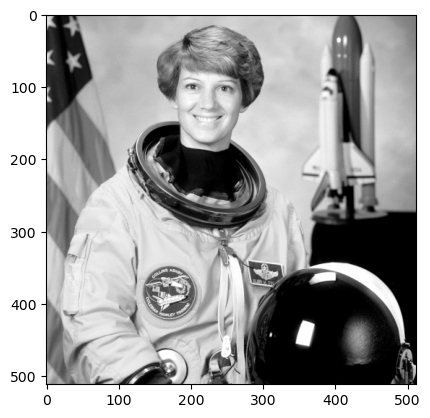

In [13]:
plt.imshow(red, cmap='gray')

Can you display other channels of this color image before heading to your first task below? Simply create a new cell under this cell (Keyboard shortcut: b) and write code to display the other channels. Do the channels appear different - why or why not?

## Part A (5 points)
Load a camera image using the [data module](https://scikit-image.org/docs/stable/api/skimage.data.html) and store in variable `camera`. Then display the image and print it's shape. How many color channels does it have? 

(512, 512)


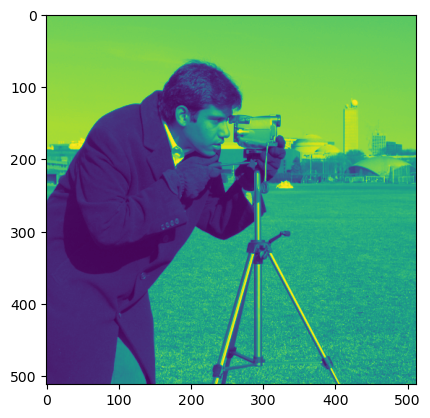

In [14]:
### BEGIN SOLUTION
#filename = os.path.join(skimage.data_dir, 'camera.png')
camera = data.camera()#io.imread(filename)
plt.imshow(camera)
print(camera.shape)
### END SOLUTION

In [15]:
#This is a gray-scale image. 
assert len(camera.shape) == 2
print("Test case passed!")

Test case passed!


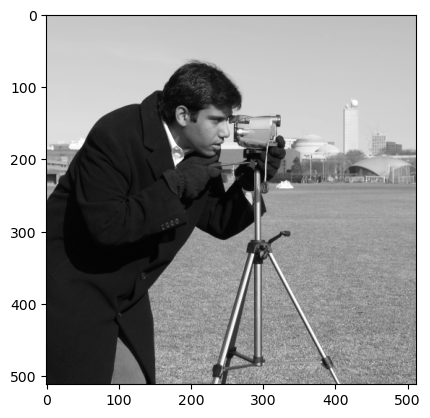

In [16]:
plt.imshow(camera, cmap='gray')

You should see a gray-level image of a cameraman!

Note: Instead of using the `skimgage data` library to load certain images (example for loading the astronaut image using `data.astronaut()`), we can use a **function** from the [scikit-image](https://pypi.org/project/scikit-image/) package to import an image. That function called ```imread``` is located in the submodule called ```io``` and can be simply accessed using ```skimage.io.imread()```. The ```imread()``` function needs an input, which is just the **location of the image**, and that location can either be the **path** to the file on our computer or a **url** of an online place where the image is stored.

For now, we will just use the `skimgage data` and load back the astronaut image.

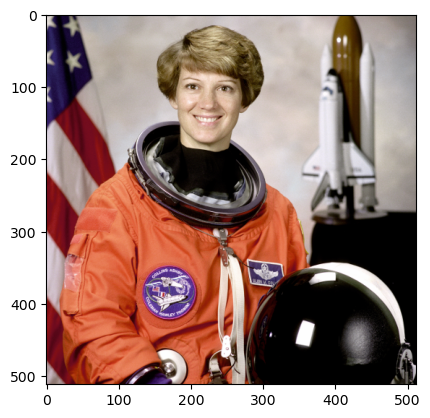

In [17]:
img = data.astronaut()
plt.imshow(img)

Since images are numpy arrays, we can index into these arrays to determine pixel value at a specific location or to acess parts of the image

In [18]:
#pixel value at top left pixel corresponding to row=0 and column=0
img[0,0]

array([154, 147, 151], dtype=uint8)

Let's say we want to focus our attention on a region in the middle of the image. We can for example take the rows 200-350 and columns 250-400. Instead of just using single coordinates we can now extract that part of the image using a **range** of pixels, the range being indicated via the ```:``` symbol. Here we write:

In [19]:
cropped = img[200:350, 250:400].copy()

**Note that we additionally use here the ```copy``` method. This ensures that whatever modification we make to the cropped version doesn't affect the original image!**.

We can again plot this cropped image:

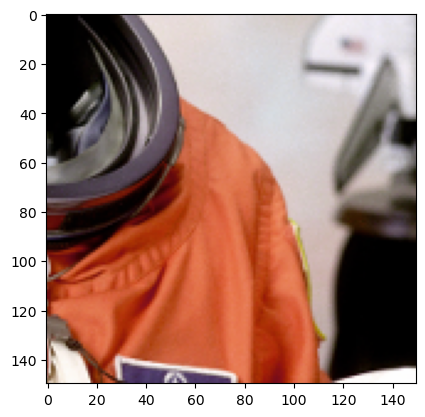

In [20]:
plt.imshow(cropped)

We can also check again the size of this cropped image. We expect 150 rows and 150 columns:

In [21]:
cropped.shape

(150, 150, 3)

We can simply display one color channel by selecting only one of the channels. Specifically, if we want the first channel we need:
- all rows of the first dimension: ```:```
- all columns of the second dimension: ```:```
- the first channel of the third dimension: ```0```

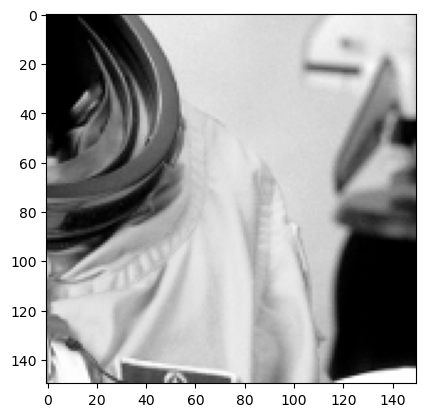

In [22]:
cropped_red = cropped[:,:,0]
plt.imshow(cropped_red, cmap = 'gray')

Again, since images are just numpy arrays, we can apply any of the methods that operate on the entire array such as mutiplying/dividing by a fixed number, taking square root pixel-wise, and so on. We can use methods to find the minimum pixel value, or the average pixel value, and so on. Or find how many pixel values are above a certain threshold (number).

In [23]:
#Divide each of the pixel values in the cropped region by 2
cropped_red/2

array([[  0. ,   0. ,   0. , ..., 111. , 105.5, 102. ],
       [  0. ,   0. ,   0. , ..., 109.5, 106. , 101. ],
       [  0. ,   0. ,   0. , ..., 109. , 106.5, 101. ],
       ...,
       [ 80. ,  64. ,  74. , ..., 127. , 127. , 127. ],
       [ 70. ,  69.5,  95.5, ..., 127. , 127. , 127. ],
       [ 72.5, 105.5, 109.5, ..., 127. , 127. , 127. ]])

In [24]:
#Average pixel value in the cropped region
np.mean(cropped_red)

152.06622222222222

In [25]:
#Store mean in a variable
avg = np.mean(cropped_red)
#Find which pixels are greater than the mean
cropThresholded = cropped_red > avg
cropThresholded

array([[False, False, False, ...,  True,  True,  True],
       [False, False, False, ...,  True,  True,  True],
       [False, False, False, ...,  True,  True,  True],
       ...,
       [ True, False, False, ...,  True,  True,  True],
       [False, False,  True, ...,  True,  True,  True],
       [False,  True,  True, ...,  True,  True,  True]])

We see that the output is again a Numpy array and that it is filled with ```True``` and ```False``` values: we have a **boolean array**. Again the comparison here was done **element wise** (SO COOOOL!!): each pixel was compared to the average value and the result stored in a new array. As we are working with an image, what we have just done here is essentially **thresholding**: we created a binary image where ```True``` pixels are above the intensity threshold and ```False``` pixels are equal or below the intensity threshold. We can actually plot the result: (Does the result make sense to you!? If not, flag the instructor!)

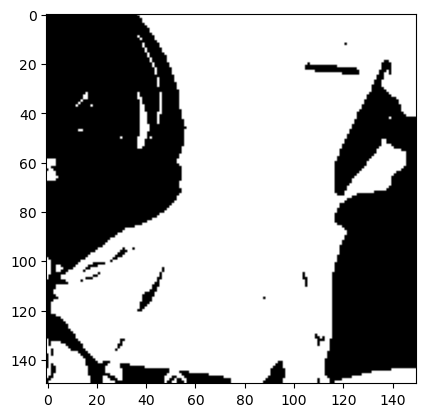

In [26]:
plt.imshow(cropThresholded, cmap='gray')

## Part B (15 points)
Write a function `modifyCameraImage` that takes a single parameter `k` representing the number of rows and columns in the middle of the image. This function:
 - Loads the image "camera.png" and stores it in a variable `camera`.
 - Assigns the middle `k` rows and middle `k` columns with `255` (`k` can be assumed to be even).
 - Returns the modified image. 

 **For example**, if the image size is `100x100`, and `k=20`, then the middle rows/columns are given by the slices `40:60`

Result after displaying the output of `modifyCameraImage(20)`:

![Result after calling modifyCameraImage(20)](partb_output.png "Result after calling modifyCameraImage(20)")

In [27]:
def modifyCameraImage(k):
    """Loads the camera image. Modifies middle k rows and middle k columns with 255 and returns the modified image.
    """
    ### BEGIN SOLUTION
    camera = data.camera()
    (rows, cols) = camera.shape
    shift = k//2
    camera[rows//2-shift:rows//2+shift, :] = 255
    camera[:, cols//2-shift:cols//2+shift] = 255
    return camera
    ### END SOLUTION

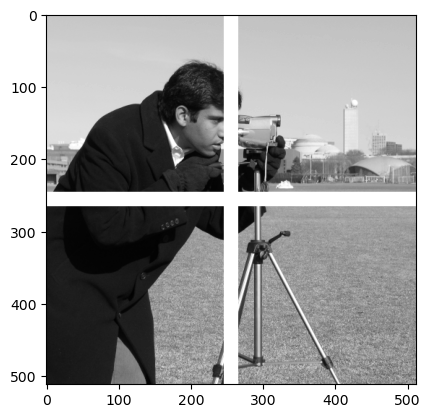

In [28]:
#double-check that by passing 20 to the function, there is a bright "+" looking sign in the middle of the image
modifiedCamera = modifyCameraImage(20)
plt.imshow(modifiedCamera, cmap = 'gray')

In [29]:
#test the functions with different parameter values
modifiedCamera = modifyCameraImage(0)
assert np.median(modifiedCamera) == 152
modifiedCamera = modifyCameraImage(100)
assert np.median(modifiedCamera) == 204
print("Test cases passed!")

Test cases passed!


## Part C (20 points)
Write a function `subtractCameraImage` to
 - Subtract the original camera image from the modified camera image obtained by calling `modifyCameraImage`.
 - Return the resulting image
 

In [30]:
def subtractCameraImage(k):
    """Returns an image obtained by subtracting the original camera image (c) from the modified camera image (m) 
    i.e. returns m - c (NOT c - m)
       
    """
    #Note: do NOT use loops. 
    #Use the functions already defined to modify the camera image. 
    
    #The code below should not be more than 3 lines of code (and can be just a single line of code as well!).
    
    ### BEGIN SOLUTION
    return modifyCameraImage(k) - data.camera()
    ### END SOLUTION


Result after calling `subtractCameraImage(100)`:

![Result after calling subtractCameraImage(100)](partc_output.png "Result after calling subtractCameraImage(100)")

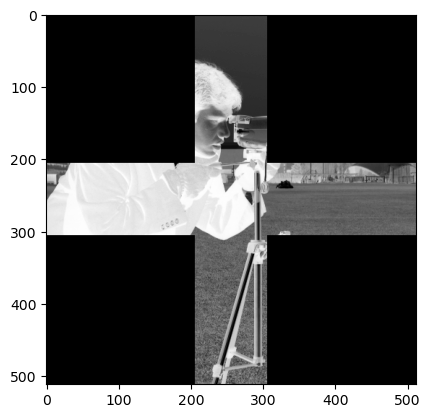

In [31]:
#call subtractCameraImage and examine the output. 
#Does it align with your expectations? (Everything is dark but the  center "+" portion has the negative of the image) 
#If you are not sure, ask the instructor!

subImg = subtractCameraImage(100)
plt.imshow(subImg, cmap = 'gray')

In the resulting image, let us find number of pixels that are oustide the center "+". This is implemented, next, in the function `findPixelsOutsidePlus`. Yes, this function is already implemented for you BUT note:

 - how to make subplots (multiple plots in the same figure)
 - how was the computation done to find the pixels outside the center "+"

Not making sense?: Flag the instructor!


In [32]:
def findPixelsOutsidePlus(k):
    '''
    Calls the subtractCameraImage fuction and, in the resulting image, 
    finds and returns the number of pixels that are NOT in the center + 
    '''
    
    subImg = subtractCameraImage(k)
    
    #Set figure size of the upcoming plots 
    plt.figure(figsize=(9, 9)) 
    # Set up a subplot grid that has height 2 and width 1,
    # and set the first such subplot as active.
    plt.subplot(2, 1, 1)
    # Make the first plot
    plt.imshow(data.camera(), cmap = 'gray')

    # Set the second subplot as active, and make the second plot.
    plt.subplot(2, 1, 2)
    plt.imshow(subImg, cmap = 'gray')

    #Compute number of pixels that are NOT in the center "+"
    (nrows, ncols) = subImg.shape
    
    #Number of pixels in the center "+"
    numPlusPixels = k*ncols + k*nrows - k*k

    #Remaining pixels
    numZeroPixels = nrows*ncols - numPlusPixels
    return numZeroPixels

Test case passed!


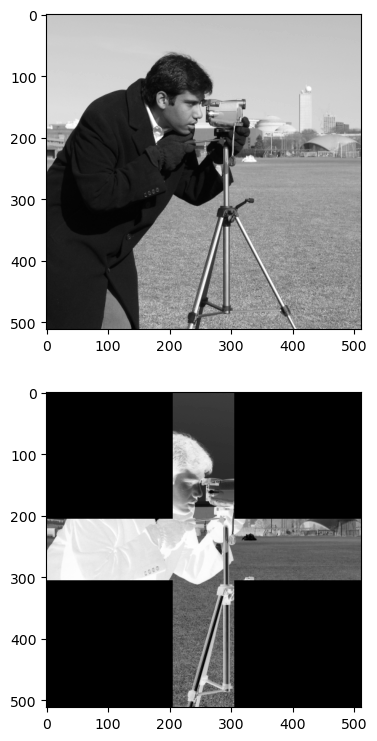

In [33]:
numZeroPixels = findPixelsOutsidePlus(100)
assert(numZeroPixels == 169744)
print("Test case passed!")

Test case passed!


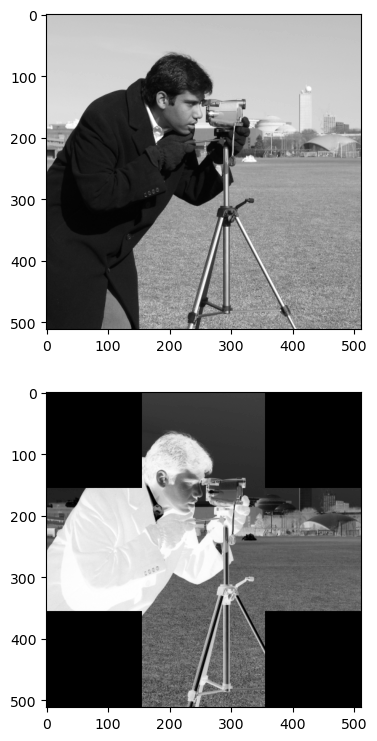

In [34]:
numZeroPixels = findPixelsOutsidePlus(200)
assert(numZeroPixels == 97344)
print("Test case passed!")

## Part D (20 points)
Write a function `findPixelsAbove(k)` to
 - Call `subtractCameraImage` with parameter `k` and store result in variable `crossneg`. 
 - Create a boolean array where only places in ```crossneg``` which are larger than a threshold `200` are ```True```. 
 - **Display** the boolean array (thresholded image)
 - Return an array containing all the pixels in ```crossneg``` which are `True` in the boolean array (recall `Boolean array Indexing` from the intro notebook?).
 

*Note: Avoid loops. A single line of code per bullet point above is needed.*

In [35]:
def findPixelsAbove(k):
    """Returns an array containing pixel values in crossneg that are greater than a threshold (200)
    """
    ### BEGIN SOLUTION
    crossneg =  subtractCameraImage(k)
    bool_idx = crossneg > 200
    plt.imshow(bool_idx, cmap = 'gray')
    return crossneg[bool_idx]
    ### END SOLUTION


(51528,)
Test case passed!


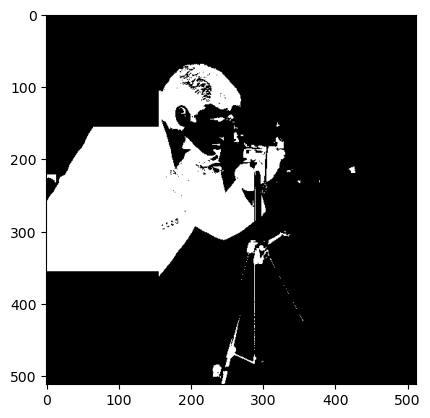

In [36]:
val = findPixelsAbove(200)
print(val.shape)
assert(val.shape[0] == 51528)
print("Test case passed!")

Test case passed!


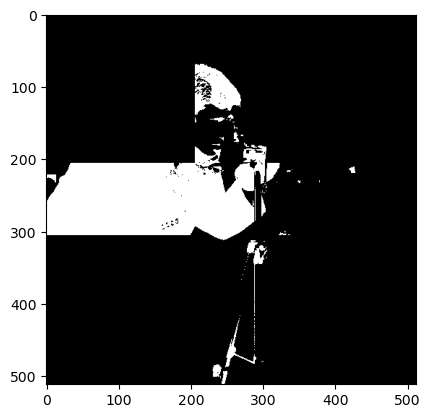

In [37]:
val = findPixelsAbove(100)
assert(val.shape[0] == 32359)
print("Test case passed!")

## Part E (BONUS - not graded)

 - Call and display the image returned by `subtractCameraImage` with different arguments.
 - Call and display the image returned by `findPixelsAbove` with the same arguments (Function `findPixelsAbove` should have displayed an image.)

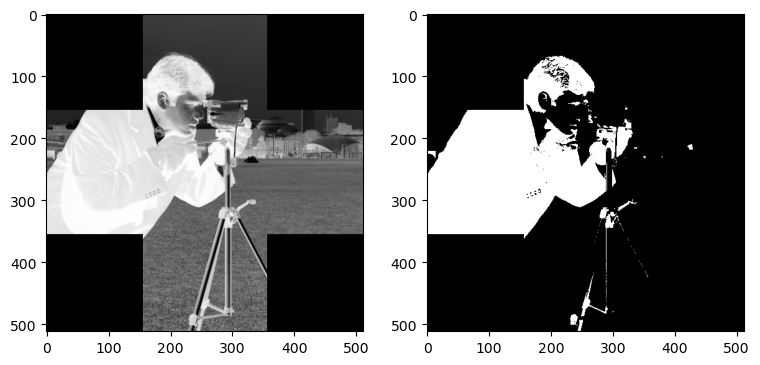

In [38]:
#Code for Part E

### BEGIN SOLUTION
k=200
crossneg =  subtractCameraImage(k)
plt.figure(figsize=(9, 9)) 
# Set up a subplot grid that has height 1 and width 2,
# and set the first such subplot as active.
plt.subplot(1, 2, 1)
plt.imshow(crossneg, cmap = 'gray')
plt.subplot(1, 2, 2)
v = findPixelsAbove(k)
### END SOLUTION

## Part F (BONUS - not graded)
 
Write a function that takes a color image as a parameter, an integer for the channel, and two tuples storing `top-left` and `bottom-right` coordinates (which will be used for cropping). Each tuple stores 2 values (row, column). So, for example, `top-left` tuple has two components: row corresponding to `top-left` coordinate and column corresponding to `bottom-right` coordinate.
 
 - Your function should give an error and return 1 if the image is not a color image. 
 - Your function should give an error and return 1 if any of the tuple is outside the range of the image. 
 - Your function should give an error and return 1 if channel is invalid. 


 - If no error, the function displays the coresponding channel of the color image. 
 - Crops the gray image based on the information contained in the tuples and displays the cropped image.
 - Returns 0 if there was no error.
 
**Testing**
 - You must test your code with different test cases that test all the parameters of the function and return values.
 

*Note: NO loops. *

In [39]:
def partF(img, channel, top_left, bot_right):
    """
    Finds a channel of the color image and crops it between top_left and bot_right coordinates
    """
    ### BEGIN SOLUTION
    #print(img.shape[2], len(img.shape))
    if len(img.shape) != 3:
        print("Error: not a color image")
        return 1
    
    if channel < 0 or channel > 2:
        print("Error: channel invalid")
        return 1
    
    height = img.shape[0]
    width = img.shape[1]
    
    if top_left[0] < 0 or top_left[1] < 0 or bot_right[0] >= height or bot_right[1] >= width:
        print("Error: cropping coordinates incorrect")
        return 1
    
    newImg = img[:, :, channel]
    cropped = newImg[top_left[0]:bot_right[0], top_left[1]:bot_right[1]].copy()
    
    plt.imshow(cropped, cmap = 'gray')
    return 0
    ### END SOLUTION

0


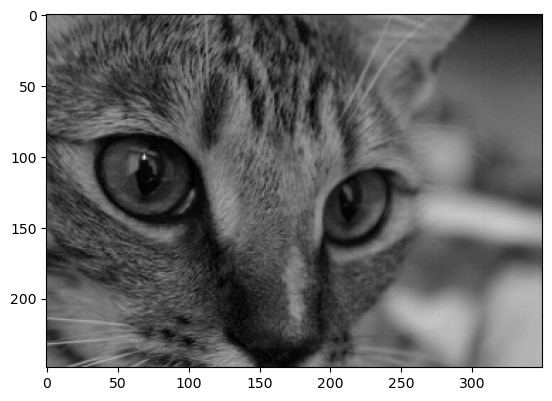

In [40]:
# add test cases for part F
# ensure test cases cover all the situations that result in the return value of 1
# ensure test cases comprise different arguments for img and channel

### BEGIN SOLUTION
img = data.cat() #data.cell() #
#plt.imshow(img)
top_left = (1, 100)
bot_right = (250, 450)
channel = 2
ret = partF(img, channel, top_left, bot_right)
print(ret)
### END SOLUTION